# VECTRA-X · 02 — Multi-label Modeling

Trains the **pre-lab** binary-relevance model (fast), reports per-label metrics, and loads the full pre-lab/lab-aware/full **leaderboard** produced by the pipeline.

*The full 3-track × 6-model leaderboard is precomputed (≈5 min); here we retrain only the headline pre-lab model for a live, fast demonstration.*

In [1]:
# --- robust project bootstrap: works whether launched from notebooks/ or root ---
import sys, os
from pathlib import Path
p = Path.cwd()
while not (p / 'src').exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p)); os.chdir(p)
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 160)
from IPython.display import Image, display
from src import report_utils as ru
cfg = ru.load_config(); RS = cfg['project']['random_state']
FIG = ru.resolve(cfg['paths']['figures']); TAB = ru.resolve(cfg['paths']['tables'])
print('Project root:', p)


Project root: C:\Users\rapha\Documents\VSCode\Kaggle\FIT\vectra_x_project


In [2]:
from src import (data_loader as dl, label_detection as ld, leakage_audit as lk,
                 preprocessing as pp, modeling as M, evaluation as ev)
df = dl.load_raw(cfg)
labels = ld.detect_labels(df, cfg); y = labels['y']; active = labels['active_labels']
feat_cols = ld.feature_columns(df, labels['label_columns_raw'], cfg)
leak = lk.audit_leakage(df, y, feat_cols, {}, cfg)
X_pre, meta = pp.make_feature_frame(df, leak['feature_sets']['PRE_LAB_TRIAGE'], cfg)
print('pre-lab design matrix:', X_pre.shape)

02:44:07 | INFO    | src.data_loader | Loaded raw CSV with encoding=utf-8 sep=';' -> 300 rows x 109 cols


02:44:08 | INFO    | src.label_detection | Detected 8 label columns -> 5 ACTIVE ['malaria', 'other_diseases', 'dengue', 'typhoid', 'yellow_fever'], 3 INACTIVE ['chikungunya', 'zika', 'option_8']


02:44:09 | INFO    | src.leakage_audit | Leakage audit -> PRE_LAB=82, LAB_AWARE=98, FULL=99 features (lab-test=16, research-only=1).


02:44:09 | INFO    | src.preprocessing | Feature frame: 82 cols (11 numeric, 66 binary, 5 indicators); dropped 7 constant columns.


02:44:09 | INFO    | src.preprocessing | Dropped constant columns: ['Inflammation de conjonctivite', 'Rougeur faciale (Facial flushing)', 'Sudation excessive (Profuse sweating)', 'Maladie rhumatismale', 'Maladie auto immune', 'Allergies', 'Cancer']


pre-lab design matrix: (300, 82)


## Out-of-fold CV — pre-lab, compare a few models (fast)

In [3]:
splits = M.make_cv_splits(y, cfg['modeling']['cv_folds'], RS)
rows = []
for name in ['logreg','random_forest','extra_trees','hist_gb']:
    oof = M.cross_val_proba(name, meta, X_pre, y, splits, RS)
    rows.append({'model': name, **ev.multilabel_summary(y, (oof>=0.5).astype(int), oof)})
pd.DataFrame(rows).sort_values('macro_pr_auc', ascending=False)

,model,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,subset_accuracy,jaccard_samples,macro_recall,macro_precision,macro_roc_auc,macro_pr_auc
2,extra_trees,0.8297,0.5563,0.8340,0.8402,0.110,0.6167,0.7864,0.5830,0.5369,0.7967,0.5542
1,random_forest,0.8469,0.5250,0.8206,0.8533,0.094,0.6600,0.8050,0.5094,0.5521,0.7932,0.5531
0,logreg,0.7224,0.5444,0.7825,0.7239,0.188,0.3867,0.6402,0.6446,0.5132,0.7663,0.5258
3,hist_gb,0.8278,0.4909,0.8000,0.8284,0.104,0.6367,0.7792,0.4713,0.5258,0.7297,0.5108


## Held-out test — best pre-lab model, per-label metrics

In [4]:
tr, te = M.train_test_indices(y, cfg['modeling']['test_size'], RS)
best = 'extra_trees'
model = M.BinaryRelevanceModel(best, meta, RS).fit(X_pre.iloc[tr], y.iloc[tr])
proba = model.predict_proba(X_pre.iloc[te])
pl = ev.per_label_metrics(y.iloc[te], (proba>=0.5).astype(int), proba, active)
pl

,label,support_pos,precision,recall,f1,roc_auc,pr_auc,tp,fp,fn,tn,false_negative_rate
0,malaria,67,0.8816,1.0000,0.9371,0.6970,0.9421,67,9,0,1,0.0000
1,other_diseases,25,1.0000,0.9600,0.9796,0.9946,0.9913,24,0,1,52,0.0400
2,dengue,14,0.4375,0.5000,0.4667,0.8016,0.4548,7,9,7,54,0.5000
3,typhoid,7,0.3333,0.2857,0.3077,0.5959,0.3106,2,4,5,66,0.7143
4,yellow_fever,3,0.0000,0.0000,0.0000,0.8829,0.3400,0,0,3,74,1.0000


## Full leaderboard & per-label metrics (precomputed by the pipeline)

,model_track,macro_f1,micro_f1,macro_pr_auc,hamming_loss,subset_accuracy
0,FULL:classifier_chain,0.6765,0.9296,0.7184,0.0430,0.8072
1,FULL:hist_gb,0.6670,0.9280,0.7095,0.0439,0.8027
2,FULL:lightgbm,0.6795,0.9101,0.7067,0.0565,0.7489
3,FULL:random_forest,0.6294,0.9102,0.7058,0.0547,0.7534
4,FULL:xgboost,0.6384,0.9274,0.7041,0.0439,0.7892
5,FULL:extra_trees,0.6560,0.9054,0.7012,0.0592,0.7578
6,FULL:logreg,0.6526,0.8454,0.6471,0.1013,0.5919
7,LAB_AWARE:classifier_chain,0.5383,0.8627,0.5722,0.0825,0.6771
8,LAB_AWARE:xgboost,0.4924,0.8597,0.5719,0.0834,0.6413
9,LAB_AWARE:hist_gb,0.5126,0.8576,0.5690,0.0852,0.6637


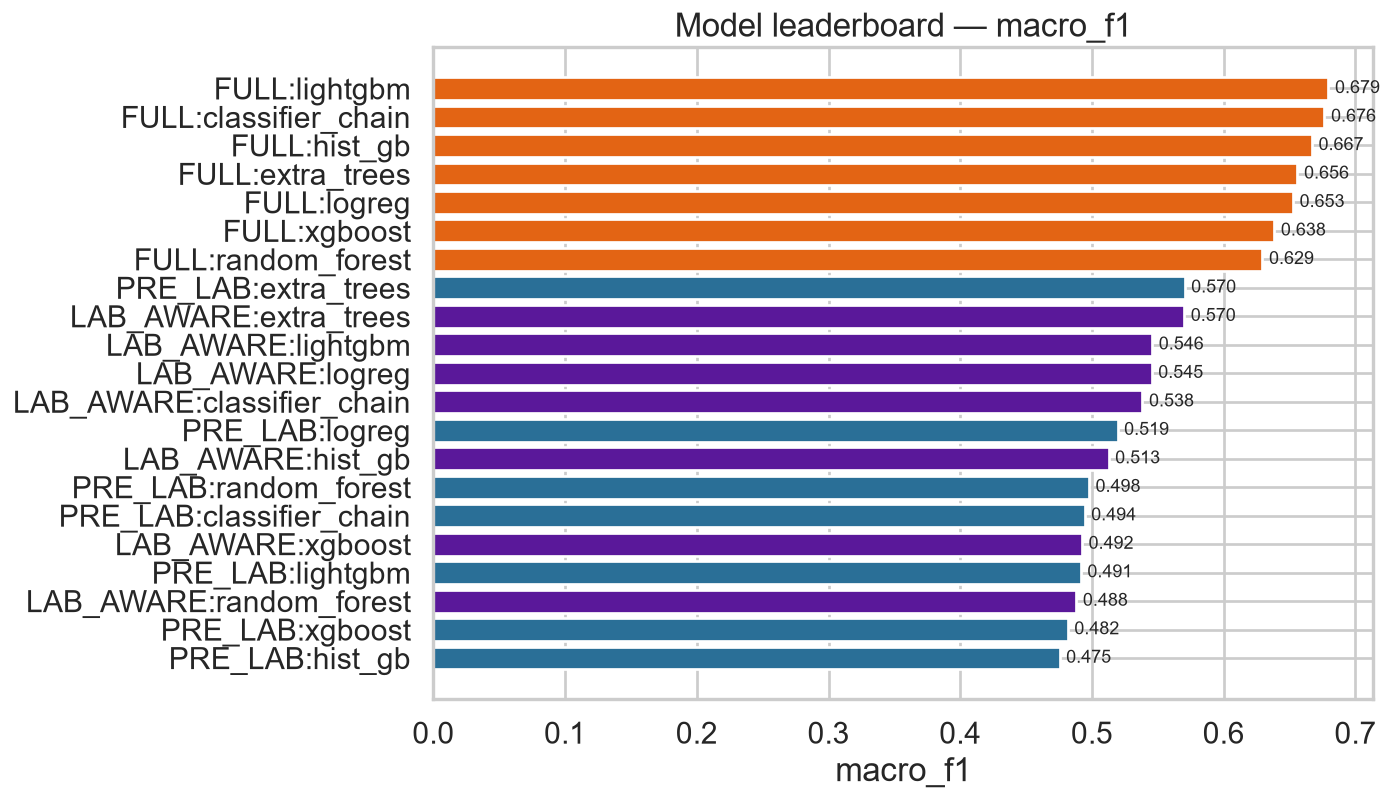

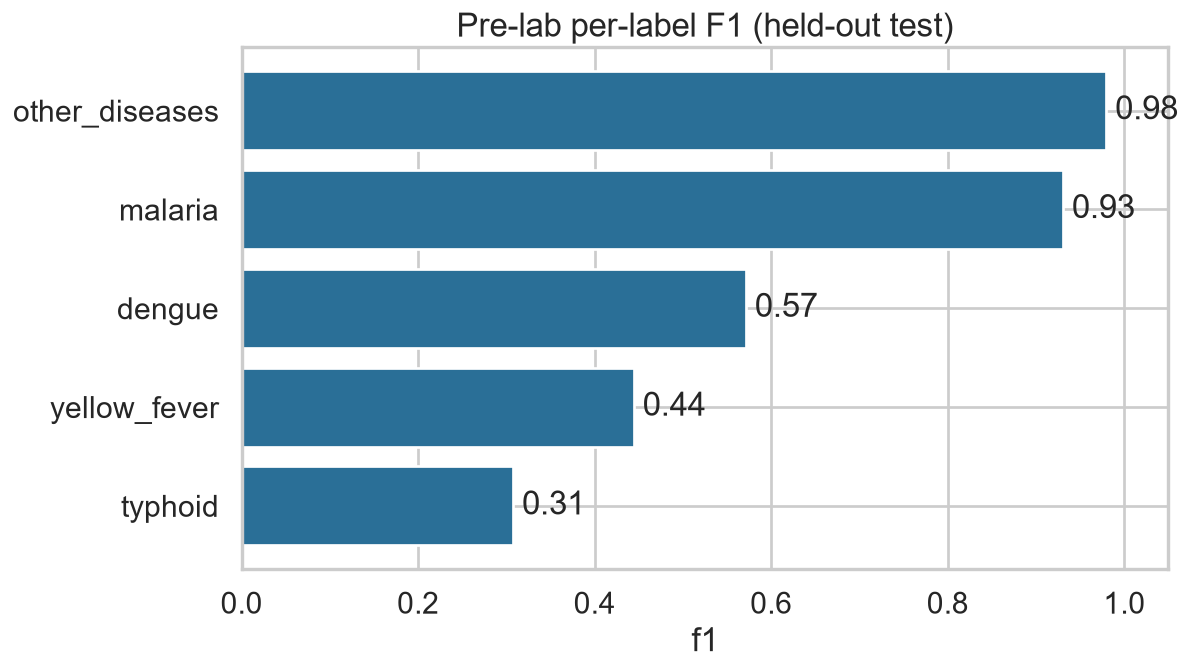

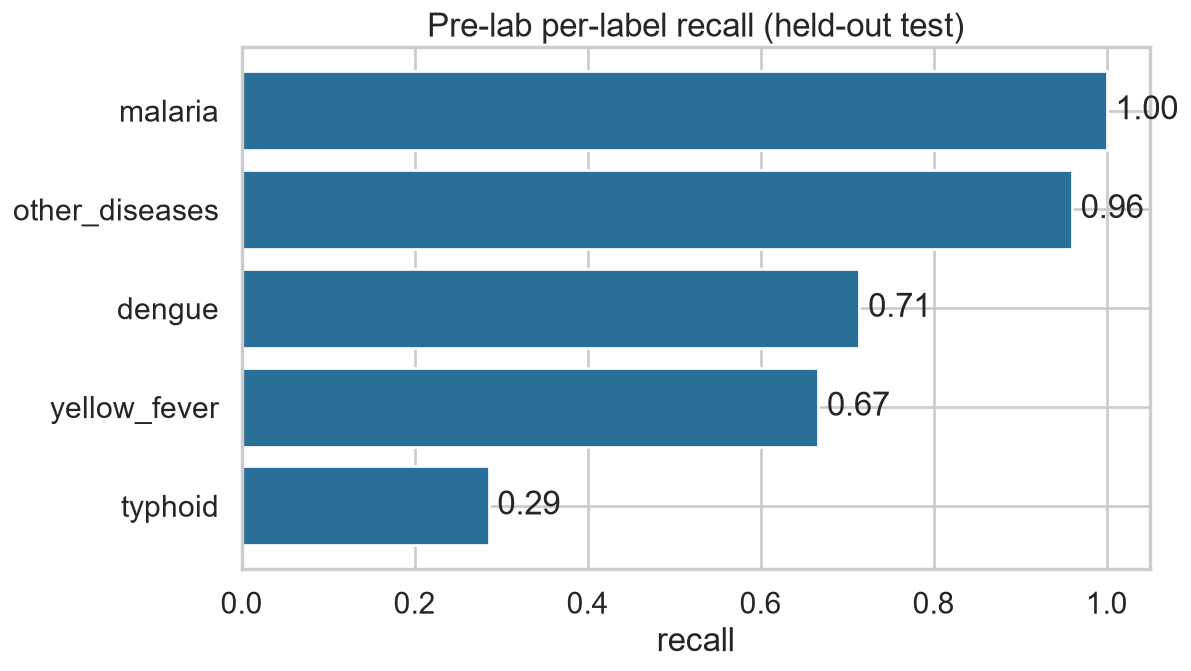

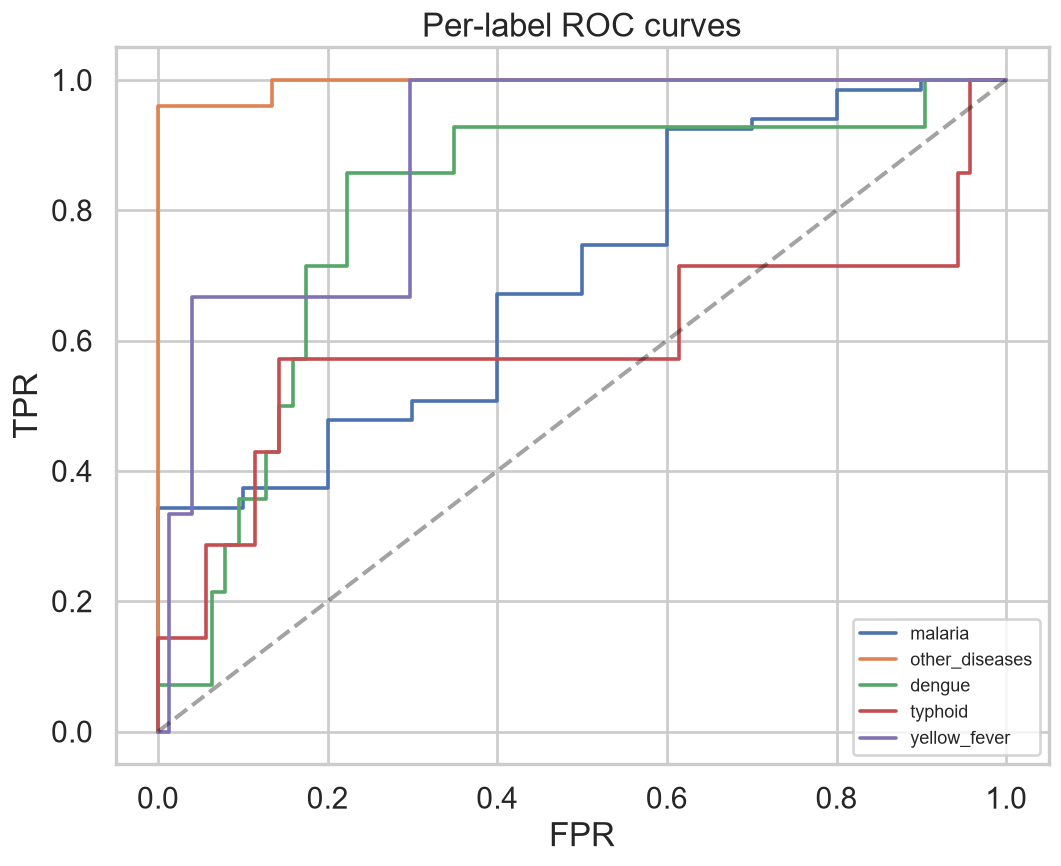

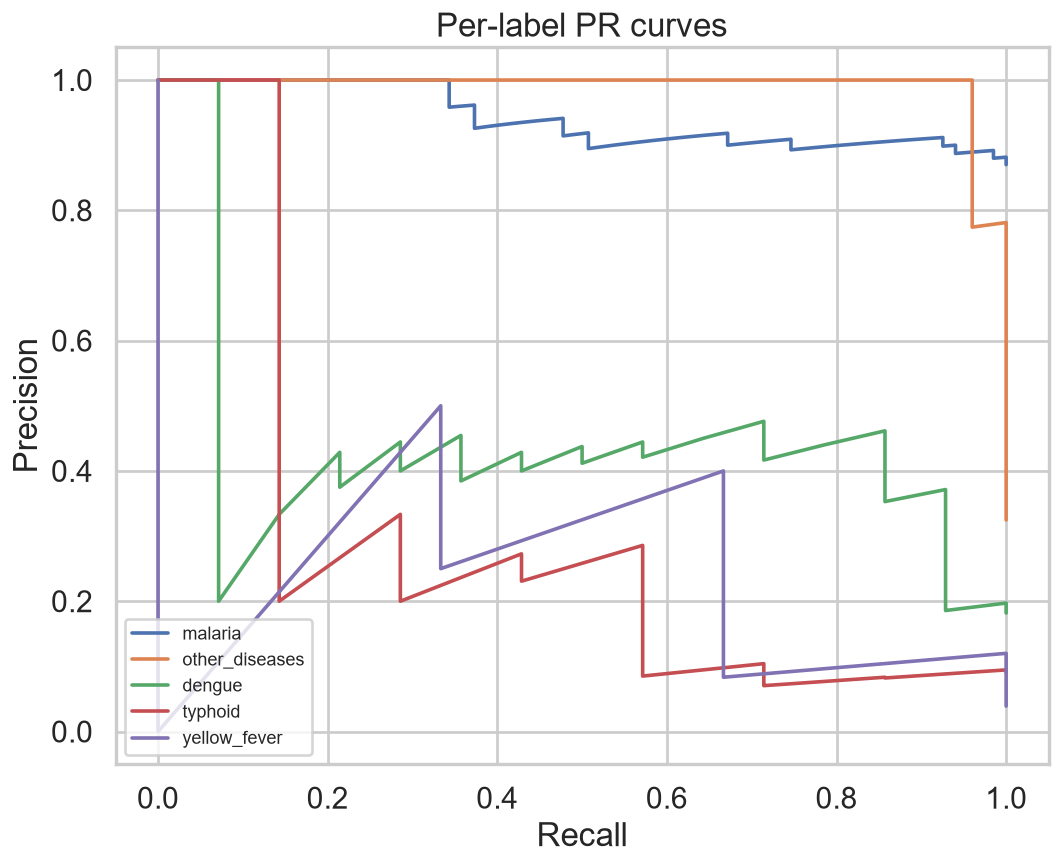

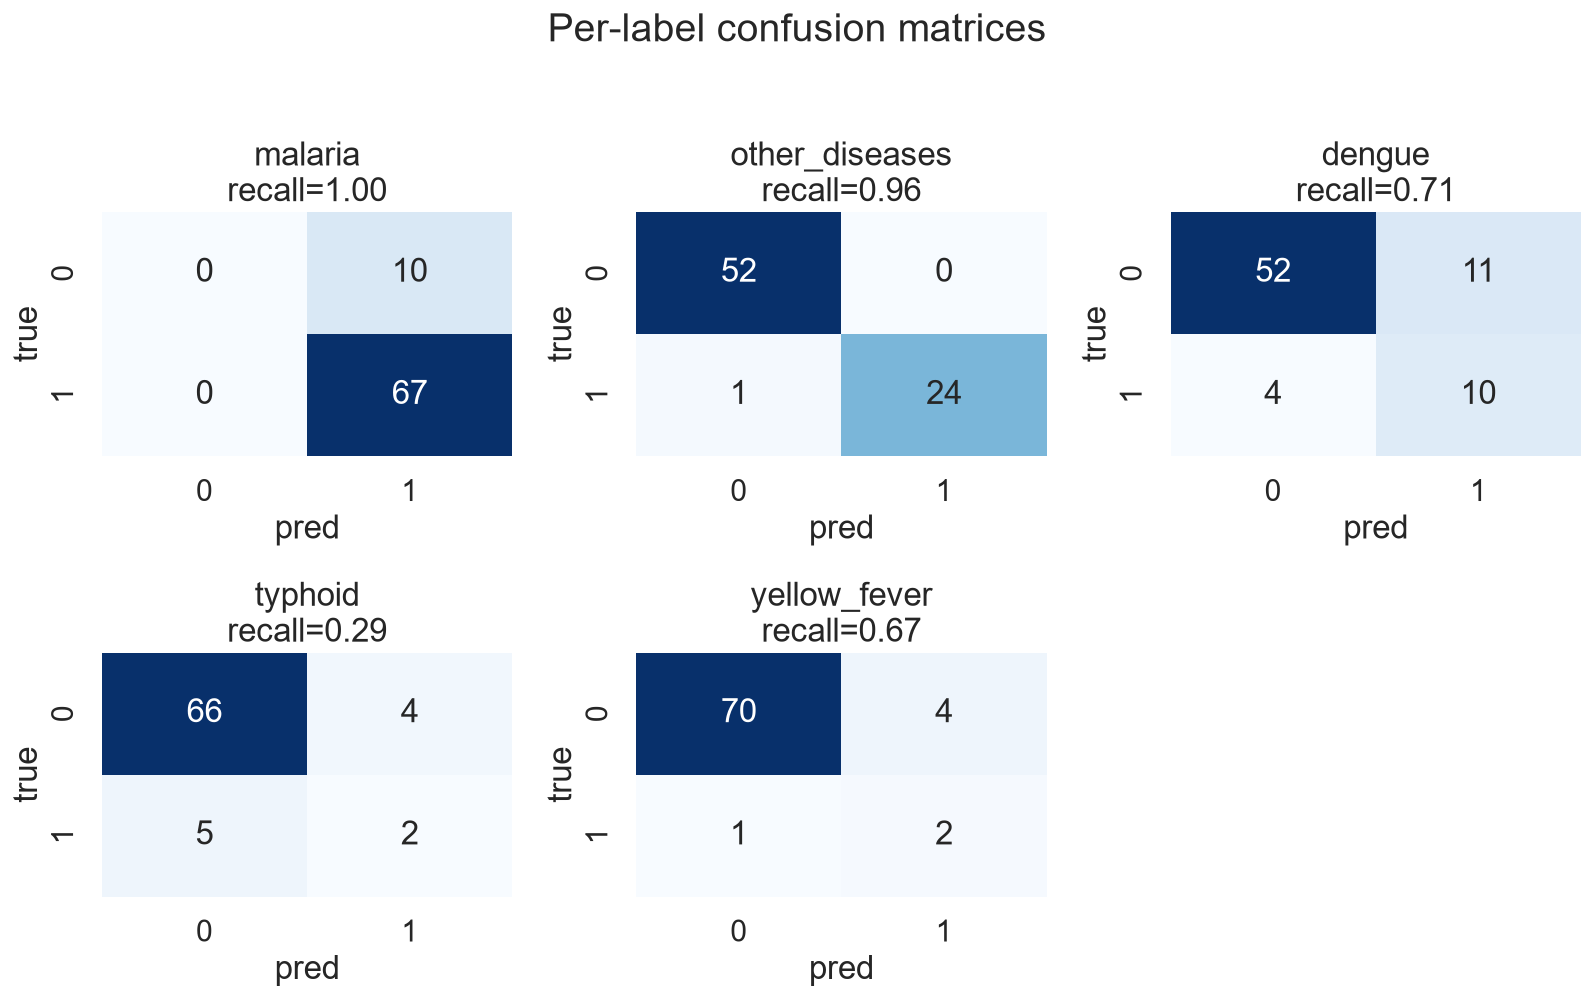

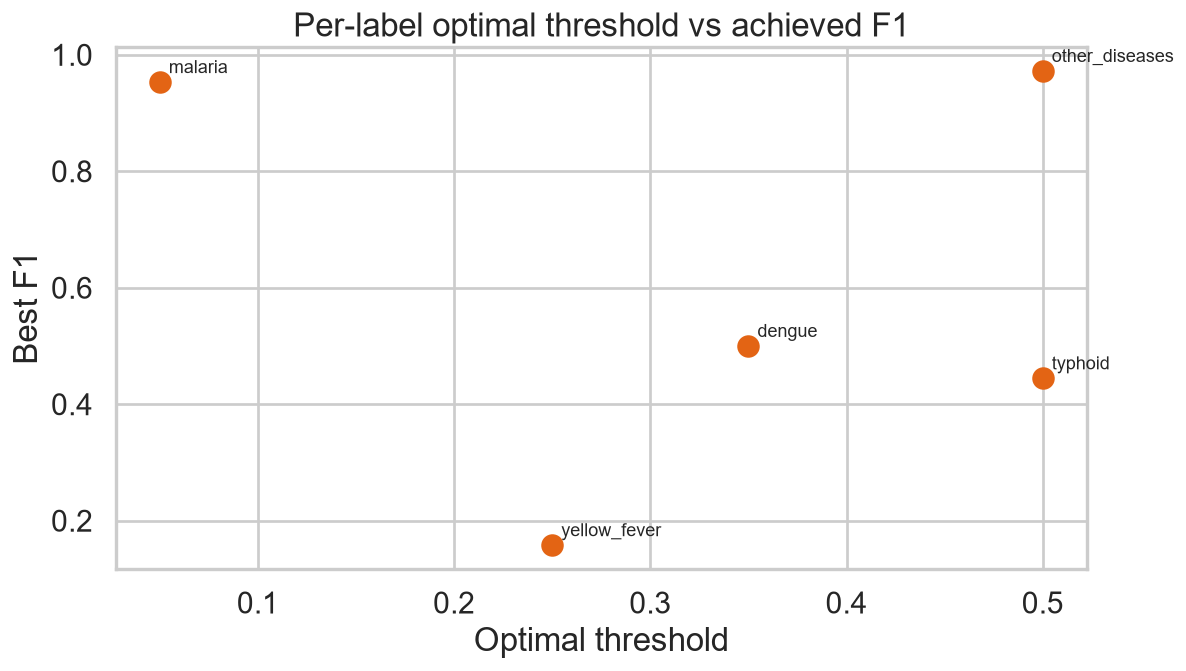

In [5]:
lb = pd.read_csv(TAB / 'model_leaderboard.csv')
display(lb[['model_track','macro_f1','micro_f1','macro_pr_auc','hamming_loss','subset_accuracy']])
for f in ['model_leaderboard.png','per_label_f1.png','per_label_recall.png',
          'roc_curves.png','pr_curves.png','confusion_matrices.png','threshold_tradeoff.png']:
    if (FIG / f).exists(): display(Image(str(FIG / f)))

**Takeaway:** the large jump in the FULL track is a *leakage artefact* (dengue F1 0.57→0.92 from *Dengue (Dengua)*). The pre-lab model is the realistic, deployable triage model.